In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


In [3]:
df = pd.read_csv("../data/Jan - May '26 Data.csv")
df['createdAt'] = pd.to_datetime(df['createdAt'], dayfirst=True)

confirmed = df[df['orderStatus'].isin(['Delivered', 'PartiallyDelivered'])]
orders = confirmed.drop_duplicates(subset='orderNumber')[[
    'orderNumber', 'customerId', 'createdAt',
    'hubName', 'shopType', 'retailerType', 'orderSource'
]].copy()

print(f'Confirmed orders: {len(orders):,}')
print(f'Retailers: {orders["customerId"].nunique():,}')

Confirmed orders: 177,340
Retailers: 8,640


In [4]:
orders_sorted = orders.sort_values(['customerId', 'createdAt']).copy()

# Next order date for each order
orders_sorted['next_order_date'] = orders_sorted.groupby('customerId')['createdAt'].shift(-1)

# Target: days until next order
orders_sorted['days_until_next_order'] = (
    orders_sorted['next_order_date'] - orders_sorted['createdAt']
).dt.days

# Drop last order per retailer (no next order to predict)
reg_df = orders_sorted[orders_sorted['days_until_next_order'].notna()].copy()

# Remove outliers — gaps > 60 days are likely churned retailers
reg_df = reg_df[reg_df['days_until_next_order'] <= 60]
reg_df = reg_df[reg_df['days_until_next_order'] >= 0]

print(f'Regression training rows: {len(reg_df):,}')
print()
print('Target variable (days_until_next_order) stats:')
print(reg_df['days_until_next_order'].describe())

Regression training rows: 168,161

Target variable (days_until_next_order) stats:
count    168161.000000
mean          4.344967
std           6.297356
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
max          60.000000
Name: days_until_next_order, dtype: float64


In [5]:
# Per-retailer historical gap stats (computed on all prior orders)
# We compute it globally here for simplicity (acceptable for Phase 2)
gap_stats = orders_sorted.groupby('customerId').agg(
    avg_gap  = ('days_until_next_order', 'mean'),
    std_gap  = ('days_until_next_order', 'std'),
    min_gap  = ('days_until_next_order', 'min'),
    max_gap  = ('days_until_next_order', 'max'),
    total_orders = ('orderNumber', 'count')
).reset_index()

gap_stats = gap_stats.rename(columns={'days_until_next_order': 'target'})
gap_stats['avg_gap']  = gap_stats['avg_gap'].fillna(7)
gap_stats['std_gap']  = gap_stats['std_gap'].fillna(0)

reg_df = reg_df.merge(gap_stats[['customerId','avg_gap','std_gap','min_gap','max_gap','total_orders']],
                       on='customerId', how='left')

# Temporal features
reg_df['day_of_week']  = reg_df['createdAt'].dt.dayofweek
reg_df['month']        = reg_df['createdAt'].dt.month
reg_df['is_weekend']   = (reg_df['createdAt'].dt.dayofweek >= 5).astype(int)

# Order source ratio
source_ratio = orders.groupby('customerId').apply(
    lambda x: (x['orderSource'] == 'App').mean()
).reset_index()
source_ratio.columns = ['customerId', 'app_order_ratio']
reg_df = reg_df.merge(source_ratio, on='customerId', how='left')

# Encode categoricals
cat_cols = ['hubName', 'shopType', 'retailerType']
for col in cat_cols:
    le = LabelEncoder()
    reg_df[col + '_enc'] = le.fit_transform(reg_df[col].fillna('Unknown').astype(str))

print('Features engineered.')
print(f'Reg dataset shape: {reg_df.shape}')

Features engineered.
Reg dataset shape: (168161, 21)


In [6]:
REG_FEATURES = [
    'avg_gap', 'std_gap', 'min_gap', 'max_gap',
    'total_orders', 'app_order_ratio',
    'day_of_week', 'month', 'is_weekend',
    'hubName_enc', 'shopType_enc', 'retailerType_enc'
]

TARGET = 'days_until_next_order'

train = reg_df[reg_df['createdAt'] <= '2026-04-30']
test  = reg_df[reg_df['createdAt'] >= '2026-05-01']

X_train = train[REG_FEATURES].fillna(0).values
y_train = train[TARGET].values
X_test  = test[REG_FEATURES].fillna(0).values
y_test  = test[TARGET].values

print(f'Train: {len(X_train):,} rows')
print(f'Test:  {len(X_test):,} rows')

Train: 138,676 rows
Test:  29,485 rows


In [7]:
# Baseline: Linear Regression
print('Training Linear Regression baseline...')
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_preds = np.clip(lr_preds, 0, 60)

print(f'Linear Regression — MAE: {mean_absolute_error(y_test, lr_preds):.2f} days')
print(f'Linear Regression — RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f} days')
print(f'Linear Regression — R2: {r2_score(y_test, lr_preds):.4f}')

Training Linear Regression baseline...
Linear Regression — MAE: 2.03 days
Linear Regression — RMSE: 3.12 days
Linear Regression — R2: 0.0532


In [8]:
# Main model: XGBoost Regressor
print('\nTraining XGBoost Regressor...')
xgb_reg = xgb.XGBRegressor(
    n_estimators    = 300,
    max_depth       = 5,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    random_state    = 42,
    n_jobs          = -1,
    tree_method     = 'hist'
)

xgb_reg.fit(X_train, y_train,
             eval_set=[(X_test, y_test)],
             verbose=50)

xgb_preds = xgb_reg.predict(X_test)
xgb_preds = np.clip(xgb_preds, 0, 60)

print(f'\nXGBoost Regressor — MAE:  {mean_absolute_error(y_test, xgb_preds):.2f} days')
print(f'XGBoost Regressor — RMSE: {np.sqrt(mean_squared_error(y_test, xgb_preds)):.2f} days')
print(f'XGBoost Regressor — R2:   {r2_score(y_test, xgb_preds):.4f}')


Training XGBoost Regressor...
[0]	validation_0-rmse:3.48925
[50]	validation_0-rmse:3.05710
[100]	validation_0-rmse:3.15206
[150]	validation_0-rmse:3.18154
[200]	validation_0-rmse:3.19901
[250]	validation_0-rmse:3.22937
[299]	validation_0-rmse:3.25581

XGBoost Regressor — MAE:  2.08 days
XGBoost Regressor — RMSE: 3.26 days
XGBoost Regressor — R2:   -0.0325


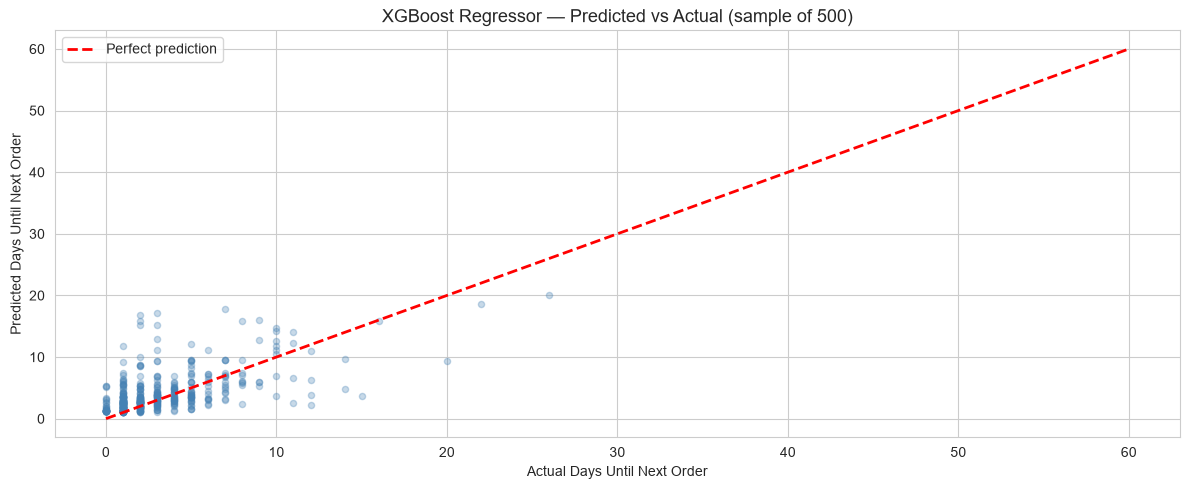

In [9]:
plt.figure(figsize=(12, 5))
plt.scatter(y_test[:500], xgb_preds[:500], alpha=0.3, color='steelblue', s=20)
plt.plot([0, 60], [0, 60], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Days Until Next Order')
plt.ylabel('Predicted Days Until Next Order')
plt.title('XGBoost Regressor — Predicted vs Actual (sample of 500)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

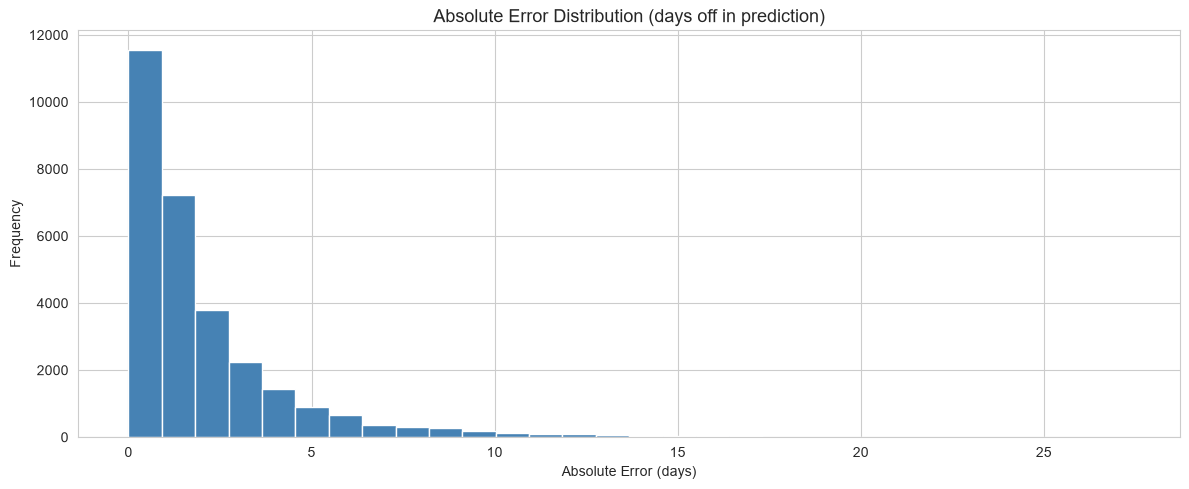

Predictions within 1 day: 42.2%
Predictions within 2 days: 66.7%
Predictions within 3 days: 79.1%


In [10]:
# Error distribution
errors = np.abs(xgb_preds - y_test)
plt.figure(figsize=(12, 5))
plt.hist(errors[errors <= 30], bins=30, color='steelblue', edgecolor='white')
plt.title('Absolute Error Distribution (days off in prediction)', fontsize=13)
plt.xlabel('Absolute Error (days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Predictions within 1 day: {(errors <= 1).mean()*100:.1f}%')
print(f'Predictions within 2 days: {(errors <= 2).mean()*100:.1f}%')
print(f'Predictions within 3 days: {(errors <= 3).mean()*100:.1f}%')

In [11]:
# For each retailer, use their most recent order to predict next order date
latest_orders = reg_df.sort_values('createdAt').groupby('customerId').last().reset_index()

X_latest = latest_orders[REG_FEATURES].fillna(0).values
latest_orders['predicted_days_until_next'] = np.clip(xgb_reg.predict(X_latest), 0, 60).round(1)
latest_orders['predicted_next_order_date'] = (
    latest_orders['createdAt'] +
    pd.to_timedelta(latest_orders['predicted_days_until_next'], unit='D')
).dt.date

schedule = latest_orders[[
    'customerId', 'createdAt', 'hubName', 'shopType',
    'avg_gap', 'predicted_days_until_next', 'predicted_next_order_date'
]].copy()
schedule = schedule.rename(columns={'createdAt': 'last_order_date', 'avg_gap': 'historical_avg_gap_days'})
schedule['last_order_date'] = schedule['last_order_date'].dt.date
schedule = schedule.sort_values('predicted_next_order_date')

print('=== NEXT ORDER PREDICTION SCHEDULE (first 20) ===')
schedule.head(20)

=== NEXT ORDER PREDICTION SCHEDULE (first 20) ===


,customerId,last_order_date,hubName,shopType,historical_avg_gap_days,predicted_days_until_next,predicted_next_order_date
5658,USR-31247,2026-01-01,Cross Line Events (EDelhi),Paan B,0.000000,0.7,2026-01-01
282,USR-110274,2026-01-01,NB Enterprises (West Delhi),Paan B,1.000000,1.3,2026-01-02
205,USR-1075,2026-01-01,Crossline Events (Noida),Paan B,1.000000,1.3,2026-01-02
4575,USR-1784,2026-01-02,Crossline Events (Noida),Paan A,0.500000,1.0,2026-01-03
6999,USR-91842,2026-01-02,Instant Foods (SED),General A,66.000000,2.6,2026-01-04
3540,USR-170584,2026-01-04,NB Enterprises (West Delhi),Paan A,1.000000,1.6,2026-01-05
5203,USR-24269,2026-01-01,Instant Foods (GZB),General C,4.000000,4.1,2026-01-05
604,USR-126165,2026-01-02,Crossline Events (Meerut),General C,3.000000,3.3,2026-01-05
3437,USR-169955,2026-01-05,NB Enterprises (West Delhi),Paan A,1.000000,0.9,2026-01-05
1186,USR-13850,2026-01-02,Crossline Events (Noida),Paan B,4.000000,3.9,2026-01-05


In [12]:
# Save regression model
with open('../models/xgboost_next_order_model.pkl', 'wb') as f:
    pickle.dump({
        'model': xgb_reg,
        'feature_cols': REG_FEATURES
    }, f)
print('Regression model saved.')

# Save schedule
schedule.to_csv('../outputs/next_order_prediction.csv', index=False)
print('Next order schedule saved to: ../outputs/next_order_prediction.csv')

print()
print('=== PHASE 2 COMPLETE ===')
mae = mean_absolute_error(y_test, xgb_preds)
print(f'Model predicts next order date with ~{mae:.1f} day average error')
print('This schedule tells the call center exactly when to call each retailer.')
print('No need to call daily — only on the predicted order date.')

Regression model saved.
Next order schedule saved to: ../outputs/next_order_prediction.csv

=== PHASE 2 COMPLETE ===
Model predicts next order date with ~2.1 day average error
This schedule tells the call center exactly when to call each retailer.
No need to call daily — only on the predicted order date.
